# PX4 QUAD-SITL — Exploração de `vehicle_gps_position`

**Dataset:** `data/UAVAttackData/Simulated - OTU Survey/PX4-QUAD-SITL/` (pastas **Normal**, **GPS Spoofing**, **Ping DoS**).

Este notebook organiza a leitura do tópico **`vehicle_gps_position`** e análises úteis para o TCC: **unidades corretas**, **cadência temporal**, **séries** de posição/incerteza e **comparação entre condições** (boxplots).


## Referência: o que cada grupo de colunas indica

| Colunas | Significado |
|---------|-------------|
| `lat`, `lon` | Graus × **1e7** (padrão PX4) |
| `alt` | Altitude AMSL em **mm** (típico neste tópico) |
| `timestamp` | **Microssegundos** desde o início do log (eixo temporal interno) |
| `eph`, `epv` | Erro estimado horizontal / vertical (m) |
| `satellites_used`, `fix_type` | Qualidade do fix GNSS |
| `vel_n_m_s`, `vel_e_m_s`, `vel_d_m_s` | Velocidade NED (m/s) |

Em **Ping DoS** o ataque é no **enlace**; este tópico pode mudar pouco — compare mesmo assim **cadência** (`Δt`) e distribuições. Para **spoofing**, espere mais sinal em **trajetória** e **eph/epv**.


In [15]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)

BASE_PATH = os.path.join("..", "data", "UAVAttackData", "Simulated - OTU Survey", "PX4-QUAD-SITL")
NORMAL = os.path.join(BASE_PATH, "Normal")
SPOOFING = os.path.join(BASE_PATH, "GPS Spoofing")
DOS = os.path.join(BASE_PATH, "Ping DoS")


def pick_vehicle_gps_csv(folder: str) -> str:
    'Retorna o caminho do CSV vehicle_gps_position (espera 1 arquivo por pasta).'
    pattern = os.path.join(folder, "*vehicle_gps_position*.csv")
    matches = sorted(glob.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"Nenhum CSV vehicle_gps_position em: {folder}")
    if len(matches) > 1:
        print(f"Aviso: vários ficheiros em {folder}; usando o primeiro: {matches[0]}")
    return matches[0]


## 1. Carregamento dos três cenários

Cada ficheiro é enriquecido com a coluna **`condition`** (rótulo experimental da pasta).


In [16]:
paths = {
    "Normal": pick_vehicle_gps_csv(NORMAL),
    "GPS Spoofing": pick_vehicle_gps_csv(SPOOFING),
    "Ping DoS": pick_vehicle_gps_csv(DOS),
}
for label, p in paths.items():
    print(f"{label}: {os.path.basename(p)}")

dfs = {}
for label, p in paths.items():
    dfs[label] = pd.read_csv(p, sep=",")

parts = [df.assign(condition=name) for name, df in dfs.items()]
df_all = pd.concat(parts, ignore_index=True)

display(df_all.groupby("condition").size().rename("n_linhas").to_frame())
df_all.head(3)


Normal: log_6_2020-8-1-21-26-31_vehicle_gps_position_0.csv
GPS Spoofing: log_0_2020-8-2-10-39-13_vehicle_gps_position_0.csv
Ping DoS: 001-2021-01-27-12-34-48-014_vehicle_gps_position_0.csv


,n_linhas
condition,
GPS Spoofing,7582
Normal,7244
Ping DoS,7232


,timestamp,time_utc_usec,lat,lon,alt,alt_ellipsoid,s_variance_m_s,c_variance_rad,eph,epv,...,vel_e_m_s,vel_d_m_s,cog_rad,timestamp_time_relative,heading,heading_offset,fix_type,vel_ned_valid,satellites_used,condition
0,14112000,0,439451638,-788968383,50107,0,0.25,0.0,1.0,1.0,...,0.00,0.01,2.484752,0,NaN,NaN,3,0,10,Normal
1,14312000,0,439451638,-788968384,50104,0,0.25,0.0,1.0,1.0,...,-0.01,0.01,4.925697,0,NaN,NaN,3,0,10,Normal
2,14512000,0,439451638,-788968383,50103,0,0.25,0.0,1.0,1.0,...,0.00,0.00,1.061129,0,NaN,NaN,3,0,10,Normal


## 2. Unidades físicas e tempo relativo

- **`lat_deg`**, **`lon_deg`**: `lat / 1e7`, `lon / 1e7`
- **`alt_m`**: `alt / 1000` (mm → m)
- **`t_rel_s`**: `(timestamp - timestamp.min()) / 1e6` → segundos desde o primeiro ponto **daquele** ficheiro
- **`dt_s`**: intervalo entre mensagens consecutivas (buracos / jitter)


In [17]:
def enrich_gps(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["lat_deg"] = out["lat"] / 1e7
    out["lon_deg"] = out["lon"] / 1e7
    out["alt_m"] = out["alt"] / 1000.0
    ts = out["timestamp"].astype("int64")
    out["t_rel_s"] = (ts - ts.min()) / 1e6
    out["dt_s"] = ts.diff() / 1e6
    out["vel_horiz_m_s"] = np.sqrt(out["vel_n_m_s"] ** 2 + out["vel_e_m_s"] ** 2)
    return out


dfs_e = {k: enrich_gps(v) for k, v in dfs.items()}
df_all_e = pd.concat(
    [enrich_gps(d.assign(condition=name)) for name, d in dfs.items()],
    ignore_index=True,
)

for name, d in dfs_e.items():
    print(name, "| linhas:", len(d), "| duração ~", float(d["t_rel_s"].max()), "s")


Normal | linhas: 7244 | duração ~ 1477.544 s
GPS Spoofing | linhas: 7582 | duração ~ 1546.552 s
Ping DoS | linhas: 7232 | duração ~ 1475.028 s


## 3. Cadência temporal (`Δt` entre mensagens)

Resumo de `dt_s` (ignorando o primeiro `NaN` por ficheiro). **Ping DoS** pode mostrar diferença aqui mesmo que posição pareça estável.


,count,mean,std,min,50%,90%,99%,max
condition,,,,,,,,
GPS Spoofing,7581.0,0.204004,0.019637,0.104,0.2,0.2,0.3,0.304
Normal,7243.0,0.203996,0.019637,0.100,0.2,0.2,0.3,0.304
Ping DoS,7231.0,0.203987,0.019683,0.100,0.2,0.2,0.3,0.304


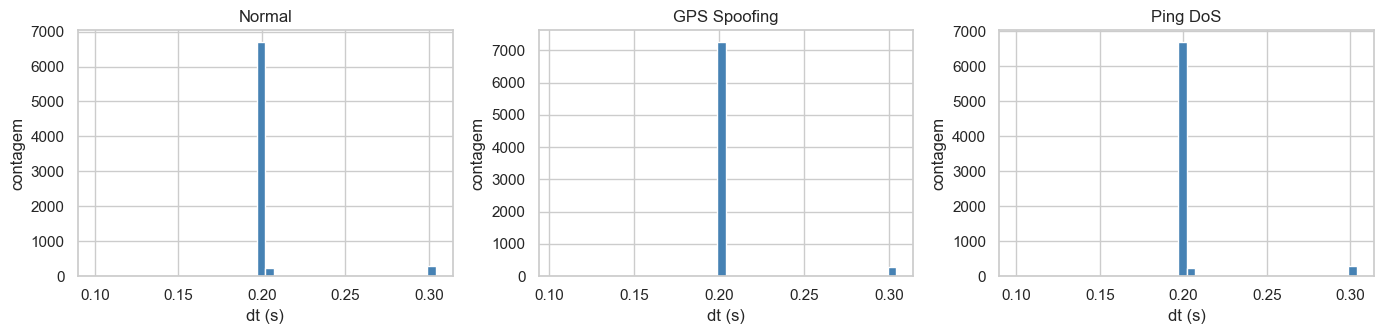

In [18]:
dt_stats = (
    df_all_e.dropna(subset=["dt_s"])
    .groupby("condition")["dt_s"]
    .describe(percentiles=[0.5, 0.9, 0.99])
    .round(6)
)
display(dt_stats)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=False)
for ax, cond in zip(axes, ["Normal", "GPS Spoofing", "Ping DoS"]):
    s = dfs_e[cond]["dt_s"].dropna()
    ax.hist(s, bins=40, color="steelblue", edgecolor="white")
    ax.set_title(cond)
    ax.set_xlabel("dt (s)")
    ax.set_ylabel("contagem")
plt.tight_layout()
plt.show()


## 4. Séries temporais — altitude e `eph`

Um painel por condição: **altitude (m)** e **eph (m)** no eixo direito — útil para ver regimes sob **GPS Spoofing**.


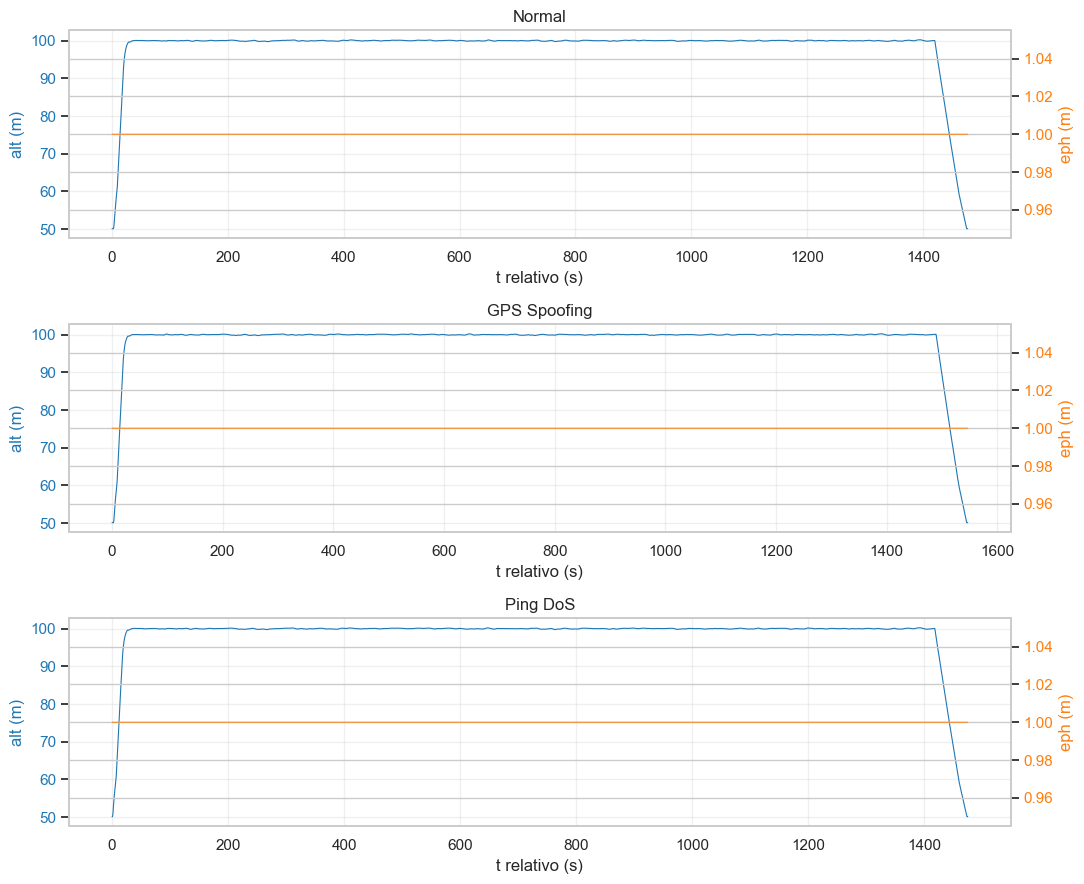

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=False)
for ax, cond in zip(axes, ["Normal", "GPS Spoofing", "Ping DoS"]):
    d = dfs_e[cond]
    ax.plot(d["t_rel_s"], d["alt_m"], color="tab:blue", lw=0.8, label="alt (m)")
    ax.set_ylabel("alt (m)", color="tab:blue")
    ax.tick_params(axis="y", labelcolor="tab:blue")
    ax2 = ax.twinx()
    ax2.plot(d["t_rel_s"], d["eph"], color="tab:orange", lw=0.8, alpha=0.85, label="eph (m)")
    ax2.set_ylabel("eph (m)", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")
    ax.set_title(cond)
    ax.set_xlabel("t relativo (s)")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Posição horizontal — variação em relação à média do voo

`lat_deg` e `lon_deg` com offset pela **média** de cada ficheiro (escala ×1e5 graus) para destacar **deriva** ou **saltos** sem comprimir a escala global.


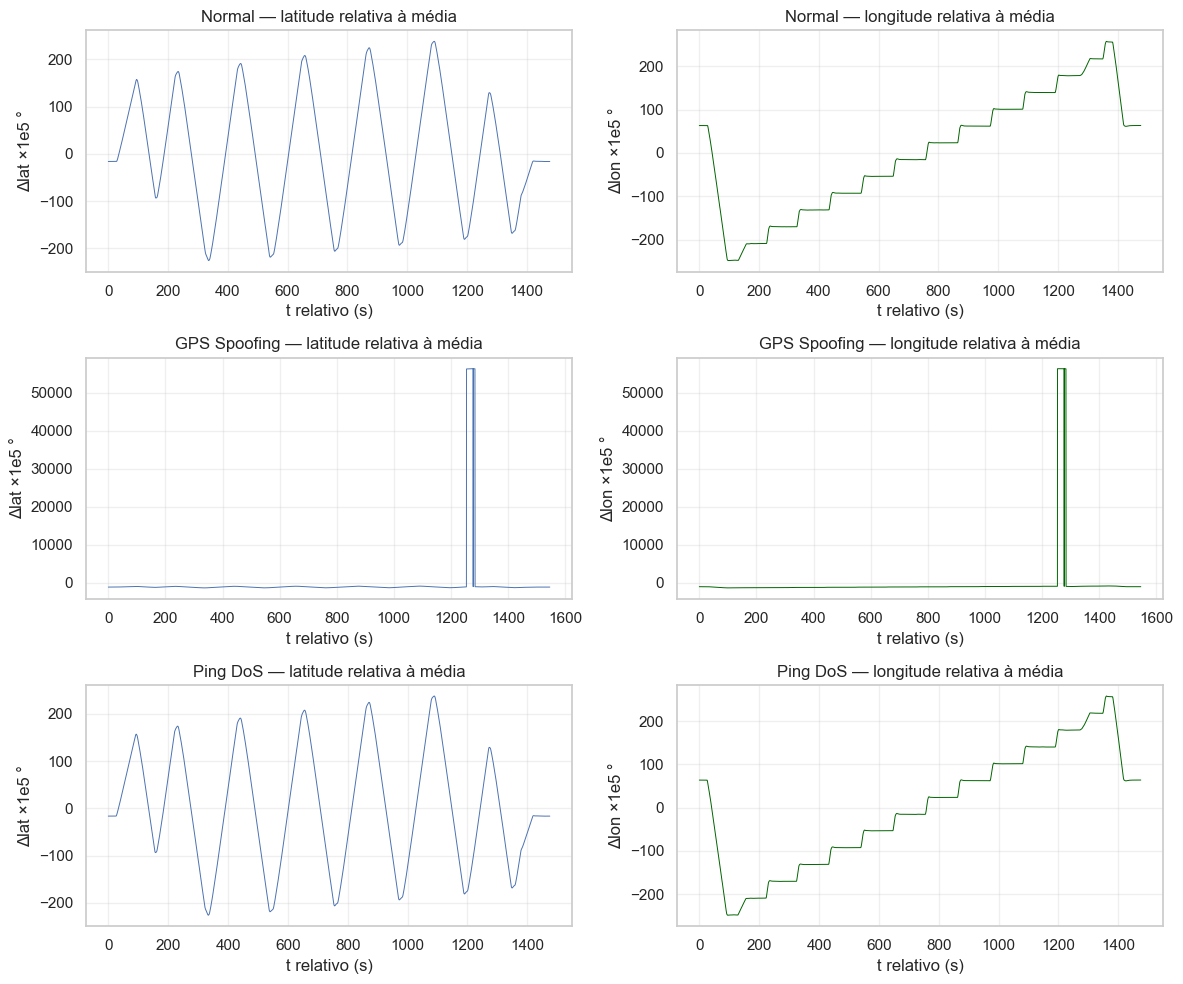

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for i, cond in enumerate(["Normal", "GPS Spoofing", "Ping DoS"]):
    d = dfs_e[cond]
    lat0, lon0 = d["lat_deg"].mean(), d["lon_deg"].mean()
    axes[i, 0].plot(d["t_rel_s"], (d["lat_deg"] - lat0) * 1e5, lw=0.7)
    axes[i, 0].set_ylabel("Δlat ×1e5 °")
    axes[i, 0].set_title(f"{cond} — latitude relativa à média")
    axes[i, 1].plot(d["t_rel_s"], (d["lon_deg"] - lon0) * 1e5, lw=0.7, color="darkgreen")
    axes[i, 1].set_ylabel("Δlon ×1e5 °")
    axes[i, 1].set_title(f"{cond} — longitude relativa à média")
    for j in range(2):
        axes[i, j].set_xlabel("t relativo (s)")
        axes[i, j].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Boxplots — `eph`, `epv`, `satellites_used`

Comparação agregada entre as três condições experimentais.


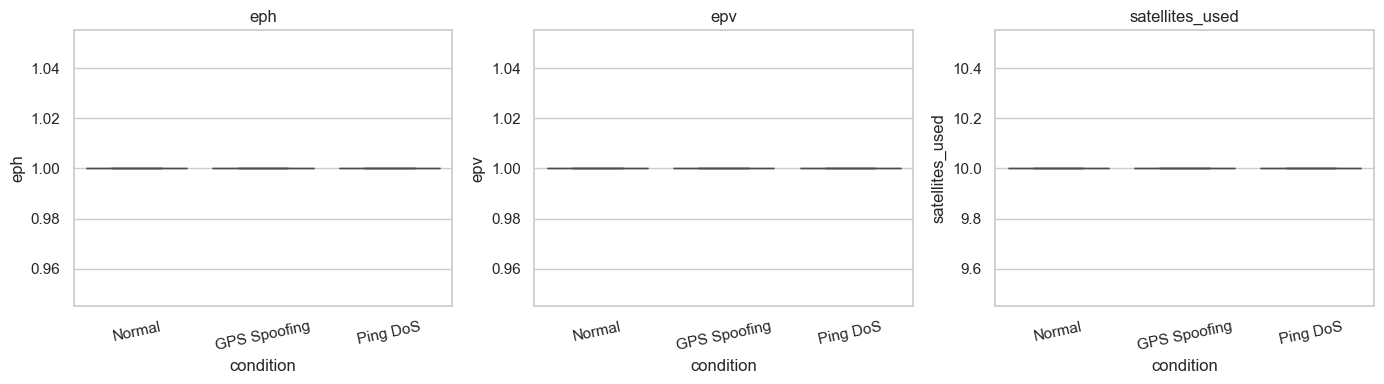

In [21]:
cols_box = ["eph", "epv", "satellites_used"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, cols_box):
    sns.boxplot(
        data=df_all_e,
        x="condition",
        y=col,
        ax=ax,
        hue="condition",
        dodge=False,
        legend=False,
    )
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=12)
plt.tight_layout()
plt.show()


## 7. Próximos passos

- **`vehicle_local_position_*`** e **`estimator_innovations_*`** do mesmo log: alinhar com `merge_asof` em `timestamp` (ver `docs/resumo.md`, §6).
- **LSTM** em janelas sobre features físicas; partição **por ficheiro/voo** para evitar vazamento.
